# Customer Personality Analysis Group Final Report
- Group Name and Number: CWL2 - G11
- Group Members: Bowen Cui, Wendi Ke, CC Liang, and Jinghan (Cathy) Zhang
- Course: STAT 301
- Date: April 16, 2026

In [1]:
# install.packages('tidyverse')
# install.packages('broom')
# install.packages('vtable')
# install.packages('naniar')
# install.packages('glmnet')
# install.packages('car')

In [2]:
library(tidyverse)
library(broom)
library(vtable)
library(naniar)
library(glmnet)
library(car)

Warning message:
"package 'tidyverse' was built under R version 4.3.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.1     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vtable' was built under R version 4.3.3"
Loading required package: kableExtra

Warning message:
"package 'kableExtra' was built under R version 4.3.3"

Attaching package: 'kableExtra'


The following object is masked from 'package:dplyr':

    group_rows


Warning message:
"package 'naniar' was built under R version 4.3.3"
Loading required package: Matrix


Attaching package:

# Introduction

Businesses are often interested in better understanding consumer behaviour, which can help marketing experts improve sales tactics and boost revenue. We may be interested not just in how a customer interacts with the business, but also in their demographic background. Data of this type helps paint a well-rounded picture of how different types of customers interact with businesses. The dataset we will work with comes from an unnamed business and contains data on customer demographics, purchasing behaviour, and engagement with marketing campaigns of that business. As such, we will use the response variable `NumCatalogPurchases`, which describes the number of purchases a customer makes via catalogue, and phrase our research question as such:

> How do customers' demographic characteristics, purchasing behaviour, and engagement with marketing campaigns relate to the number of catalogue purchases they make?

This is an inferential question, as we are interested in customers who make purchases through catalogues, and how different variables/factors relate to this response. We expect that `Income`, `Recency`, and variables on spending (`MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds`) to be the most important covariates, since they all relate to purchasing power and prior/recency of spending patterns. Demographic variables (such as `Year_Birth`, `Education`, `Marital_Status`, `Kidhome`, and `Teenhome`) will help control for demographic differences. Variables like `AcceptedCmp1–AcceptedCmp5` and `NumDealsPurchases` capture engagement with past promotions that may influence catalogue purchasing behaviour.

## Data 

In [3]:
# reading and loading data
marketing_campaign <- read_tsv("https://raw.githubusercontent.com/wend1k3/CWL2-STAT-301/refs/heads/main/marketing_campaign.csv")
num_observations <- nrow(marketing_campaign)
num_variables <- ncol(marketing_campaign)
name_type_table <- data.frame(
    variable = names(marketing_campaign),
    type = sapply(marketing_campaign, class))
row.names(name_type_table) <- NULL

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
print(paste('There are ', num_observations, ' observations, and ', num_variables, ' variables in the dataset.'))
#kable(name_type_table) #markdown output for data types table used in the following cell. 
    # Uncomment to view original output inclduing only "variable" and "type" columns.

[1] "There are  2240  observations, and  29  variables in the dataset."


### Summary of Data
|Variable            |Type      | Description|
|:-------------------|:---------|:---|
|ID                  |numeric   | Unique ID |
|Year_Birth          |numeric   | Year of birth|
|Education           |character | Education level |
|Marital_Status      |character | Marital status |
|Income              |numeric   | Yearly income|
|Kidhome             |numeric   | Number of children in households|
|Teenhome            |numeric   | Number of teenagers in household|
|Dt_Customer         |character | Date of enrollment with company|
|Recency             |numeric   | Number of days since the last purchase|
|MntWines            |numeric   | Amount spent on wine in the previous 2 years|
|MntFruits           |numeric   | Amount spent on fruits in the previous 2 years|
|MntMeatProducts     |numeric   | Amount spent on meat in the previous 2 years|
|MntFishProducts     |numeric   | Amount spent on fish in the previous 2 years|
|MntSweetProducts    |numeric   | Amount spent on sweets in the previous 2 years|
|MntGoldProds        |numeric   | Amount spent on gold in the previous 2 years|
|NumDealsPurchases   |numeric   | Number of purchases made with a discount|
|NumWebPurchases     |numeric   | Number of purchases made through the website|
|NumCatalogPurchases |numeric   | Number of purchases made through the catalogue|
|NumStorePurchases   |numeric   | Number of purchases made in store|
|NumWebVisitsMonth   |numeric   | Number of website visits in the last month|
|AcceptedCmp3        |numeric   | Whether the customer accepted a promotion offer in the 3rd campaign - 1 if yes, 0 if no|
|AcceptedCmp4        |numeric   | Whether the customer accepted a promotion offer in the 4th campaign - 1 if yes, 0 if no|
|AcceptedCmp5        |numeric   | Whether the customer accepted a promotion offer in the 5th campaign - 1 if yes, 0 if no|
|AcceptedCmp1        |numeric   | Whether the customer accepted a promotion offer in the 1st campaign - 1 if yes, 0 if no|
|AcceptedCmp2        |numeric   | Whether the customer accepted a promotion offer in the 2nd campaign - 1 if yes, 0 if no|
|Complain            |numeric   | Whether the customer complained in the last 2 years - 1 if yes, 0 otherwise|
|Z_CostContact       |numeric   | No information provided|
|Z_Revenue           |numeric   | No information provided|
|Response            |numeric   | Whether the customer accepted a promotion offer in the most recent campaign - 1 if yes, 0 if no|


### Collection
There is no documentation regarding collection methods. We assume that it comes from a comapany's internal customer data.

### Source
The data is from kaggle, user **imakash3011** at https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data. 
The data card acknowledges Dr. Omar Romero-Hernandez as the data provider. The author doesn't specify a citation format, and the dataset is under a public domain license.

## EDA and Visualization

In [5]:
#reading and loading data
marketing_campaign <- read_tsv("https://raw.githubusercontent.com/wend1k3/CWL2-STAT-301/refs/heads/main/marketing_campaign.csv")
head(marketing_campaign, 10)

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,⋯,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5524,1957,Graduation,Single,58138,0,0,04-09-2012,58,635,⋯,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344,1,1,08-03-2014,38,11,⋯,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613,0,0,21-08-2013,26,426,⋯,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646,1,0,10-02-2014,26,11,⋯,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293,1,0,19-01-2014,94,173,⋯,5,0,0,0,0,0,0,3,11,0
7446,1967,Master,Together,62513,0,1,09-09-2013,16,520,⋯,6,0,0,0,0,0,0,3,11,0
965,1971,Graduation,Divorced,55635,0,1,13-11-2012,34,235,⋯,6,0,0,0,0,0,0,3,11,0
6177,1985,PhD,Married,33454,1,0,08-05-2013,32,76,⋯,8,0,0,0,0,0,0,3,11,0
4855,1974,PhD,Together,30351,1,0,06-06-2013,19,14,⋯,9,0,0,0,0,0,0,3,11,1


#### Cleaning and Wrangling
The data is already tidy, but data types need wrangling and irrelevant columns need to be dropped.

#### Unused Variables
`Z_CostContact` and `Z_Revenue` have constant values (3 & 11), and are not adequately documented. `ID` is not relevant to our analysis. Thus, we will omit them from our analysis.

In [6]:
#dropping irrelevant variables
marketing_campaign <- marketing_campaign %>%
    select(-ID, -Z_CostContact, -Z_Revenue)

#### Missing Values

In [7]:
miss_var_summary(marketing_campaign)

variable,n_miss,pct_miss
<chr>,<int>,<num>
Income,24,1.07
Year_Birth,0,0
Education,0,0
Marital_Status,0,0
Kidhome,0,0
Teenhome,0,0
Dt_Customer,0,0
Recency,0,0
MntWines,0,0


`Income` is missing 24 values; there are no other missing values. It is appropriate to simply drop the 1.07% of incomplete rows.

In [8]:
marketing_campaign_dropna <- marketing_campaign %>% drop_na(Income)
num_observations_dropna <- nrow(marketing_campaign)
num_variables_dropna <- ncol(marketing_campaign)
print(paste('After dropping unused columns and observations with missing values, there are now ', num_observations_dropna, ' observations, and ', num_variables_dropna, ' variables in the dataset.'))

[1] "After dropping unused columns and observations with missing values, there are now  2240  observations, and  26  variables in the dataset."


#### Data Types

##### Factor Levels: `Education`
Education levels are semantically ordered, but because our model will convert ordered factors to dummies, we chose to make `Education` a non-ordered factor for ease of interpretation without changing modelling. We will inspect the unique levels.

In [9]:
data.frame(table(marketing_campaign$Education)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
2n Cycle,203,0.09062500
Basic,54,0.02410714
Graduation,1127,0.50312500
Master,370,0.16517857
PhD,486,0.21696429


`2n Cycle` likely refers to european second cycle programs, which are post-graduate degrees. There are no concerning levels.

##### Factor Levels: `Marital_Status`
`Marital_Status` is categorical. We will inspect the unique levels.

In [10]:
data.frame(table(marketing_campaign$Marital_Status)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
Absurd,2,0.0008928571
Alone,3,0.0013392857
Divorced,232,0.1035714286
Married,864,0.3857142857
Single,480,0.2142857143
Together,580,0.2589285714
Widow,77,0.0343750000
YOLO,2,0.0008928571


`Absurd`, `Alone`, and `YOLO` are outliers, with only 2-3 observations each. This could be problematic, so we will recode  `Alone` and `YOLO` to `Single`, and drop `Absurd`. 

In [11]:
marketing_campaign<- marketing_campaign %>% 
    mutate(
         Marital_Status = as.factor(Marital_Status)) %>% #making marital status a factor
    filter(Marital_Status != 'Absurd') %>% #dropping extremely rare level
    droplevels() %>% #dropping unused level
    mutate(Marital_Status = fct_collapse(Marital_Status, Single = c('Single', 'Alone', 'YOLO'))) #combining "Alone" and "YOLO" with single, at our discretion, assuming they are similar enough
data.frame(table(marketing_campaign$Marital_Status)) %>% #displaying new results after wrangling
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
Single,485,0.21671135
Divorced,232,0.10366399
Married,864,0.38605898
Together,580,0.25915996
Widow,77,0.03440572


Now, we will parse the datetime variables and confirm data types (numeric & factor).

In [12]:
# data cleaning and wrangling into a tidy format
marketing_campaign <- marketing_campaign %>%
    mutate(
           Year_Birth = as.numeric(Year_Birth),
           Income = as.numeric(Income),
           Education = as.factor(Education),
           Kidhome = as.numeric(Kidhome),
           Teenhome = as.numeric(Teenhome),
           Dt_Customer = as.Date(Dt_Customer, format="%d-%m-%Y"),
           Recency = as.numeric(Recency),
           Complain = as.factor(Complain),
           MntWines = as.numeric(MntWines),
           MntFruits = as.numeric(MntFruits),
           MntMeatProducts = as.numeric(MntMeatProducts),
           MntFishProducts = as.numeric(MntFishProducts),
           MntSweetProducts = as.numeric(MntSweetProducts),
           MntGoldProds = as.numeric(MntGoldProds),
           NumDealsPurchases = as.numeric(NumDealsPurchases),
           AcceptedCmp1 = as.factor(AcceptedCmp1),
           AcceptedCmp2 = as.factor(AcceptedCmp2),
           AcceptedCmp3 = as.factor(AcceptedCmp3),
           AcceptedCmp4 = as.factor(AcceptedCmp4),
           AcceptedCmp5 = as.factor(AcceptedCmp5),
           Response = as.factor(Response),
           NumWebPurchases = as.numeric(NumWebPurchases),
           NumCatalogPurchases = as.numeric(NumCatalogPurchases),
           NumStorePurchases = as.numeric(NumStorePurchases),
           NumWebVisitsMonth = as.numeric(NumWebVisitsMonth))
head(marketing_campaign)

Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,⋯,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<date>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1957,Graduation,Single,58138,0,0,2012-09-04,58,635,88,⋯,10,4,7,0,0,0,0,0,0,1
1954,Graduation,Single,46344,1,1,2014-03-08,38,11,1,⋯,1,2,5,0,0,0,0,0,0,0
1965,Graduation,Together,71613,0,0,2013-08-21,26,426,49,⋯,2,10,4,0,0,0,0,0,0,0
1984,Graduation,Together,26646,1,0,2014-02-10,26,11,4,⋯,0,4,6,0,0,0,0,0,0,0
1981,PhD,Married,58293,1,0,2014-01-19,94,173,43,⋯,3,6,5,0,0,0,0,0,0,0
1967,Master,Together,62513,0,1,2013-09-09,16,520,42,⋯,4,10,6,0,0,0,0,0,0,0


#### Class Imbalance
We will inspect the two categorical (`Education`; `Marital_Status`) and seven binary variables (`AccemptedCmp1` ,..., `AcceptedCmp5`, `Complain`, `Response`).

In [13]:
data.frame(table(marketing_campaign$Marital_Status)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
Single,485,0.21671135
Divorced,232,0.10366399
Married,864,0.38605898
Together,580,0.25915996
Widow,77,0.03440572


In [14]:
data.frame(table(marketing_campaign$Education)) %>% 
    rename(Count = Freq) %>% 
    mutate(Proportion = prop.table(Count))

Var1,Count,Proportion
<fct>,<int>,<dbl>
2n Cycle,203,0.09070599
Basic,54,0.02412869
Graduation,1126,0.50312779
Master,369,0.16487936
PhD,486,0.21715818


`Widow` is rare, with 3% of observations. `Basic` is rare, with 2% of observations. This is expected, and not too concerning. 

In [15]:
binary_responses <- marketing_campaign %>% 
    select(AcceptedCmp3, AcceptedCmp4, AcceptedCmp5, 
           AcceptedCmp1, AcceptedCmp2, Complain, Response) %>%
    pivot_longer(cols = everything()) %>% 
    group_by(name) %>%
    summarize(count_1s = sum(value == 1),
              count_0s = sum(value == 0),
              percent_1s = (100 * (count_1s/(count_1s + count_0s))))
    

binary_responses

name,count_1s,count_0s,percent_1s
<chr>,<int>,<int>,<dbl>
AcceptedCmp1,143,2095,6.3896336
AcceptedCmp2,30,2208,1.3404826
AcceptedCmp3,163,2075,7.2832887
AcceptedCmp4,167,2071,7.4620197
AcceptedCmp5,162,2076,7.2386059
Complain,21,2217,0.9383378
Response,333,1905,14.8793566


Generally, 1's greatly outnumber 0's. `Complain` and `AcceptedCmp2` are particularly concerning. We will be cautious with `Complain`, and create an engineered feature to address `AcceptedCmp2`.

#### Outliers

In [16]:
sumtable(marketing_campaign, out = 'return')

Variable,N,Mean,Std. Dev.,Min,Pctl. 25,Pctl. 75,Max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Year_Birth,2238,1969,12,1893,1959,1977,1996
Education,2238,,,,,,
... 2n Cycle,203,9%,,,,,
... Basic,54,2%,,,,,
... Graduation,1126,50%,,,,,
... Master,369,16%,,,,,
... PhD,486,22%,,,,,
Marital_Status,2238,,,,,,
... Single,485,22%,,,,,


`Year_Birth` and `Income` look concerning.

In [17]:
earliest_year_birth <- head(sort(marketing_campaign$Year_Birth, decreasing = FALSE), n = 5)
highest_income <- head(sort(marketing_campaign$Income, decreasing = TRUE), n = 5)

print(paste('Earliest Birth Years: ', list(earliest_year_birth)))
print(paste('Highest Incomes: ', list(highest_income)))


[1] "Earliest Birth Years:  c(1893, 1899, 1900, 1940, 1941)"
[1] "Highest Incomes:  c(666666, 162397, 160803, 157733, 157243)"


We will create cutoffs that match reasonable, real-life ranges for `Birth_Year` and `Income` to avoid significant influences from outliers and mitigate data errors.

In [18]:
marketing_campaign <- marketing_campaign %>% filter(Year_Birth >= (year(now()) - 100 ),
                                                    Income <= 200000)

#### Feature Engineering

1. `Year_Birth` -> `Age`
For intuitive interpretations.
We will use the dataset's upload date (2021) to calculate age.

2. `Dt_Customer` -> `Enrollment_Recency_Days`
To avoid treating the datetime as continuous. We will use the most recent `Dt_Customer` as reference to calculate days enrolled. 

3. `AcceptedCmp1-5` -> `AcceptedCmpAny`
To avoid class imbalace. 
`AcceptedCmpAny` combines all `AcceptedCmp...` variables; 1 represents accepting any of the 5 campaigns.

We will drop the original variables to avoid multicollinearity. 

In [19]:
marketing_campaign <- marketing_campaign %>% 
    mutate(
        Age = 2021 - Year_Birth,
        Enrollment_Recency_Days = as.numeric(max(marketing_campaign$Dt_Customer) - Dt_Customer),
        AcceptedCmpAny = if_else(
            (AcceptedCmp1 == 1 | 
            AcceptedCmp2 == 1 | 
            AcceptedCmp3 == 1 |
            AcceptedCmp4 == 1 |
            AcceptedCmp5 == 1),
            1,
            0)
        ) %>%
    select(
        -Year_Birth, 
        -Dt_Customer, 
        -AcceptedCmp1, 
        -AcceptedCmp2, 
        -AcceptedCmp3, 
        -AcceptedCmp4,
        -AcceptedCmp5)    

In [20]:
head(marketing_campaign)

Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,⋯,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Enrollment_Recency_Days,AcceptedCmpAny
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
Graduation,Single,58138,0,0,58,635,88,546,172,⋯,3,8,10,4,7,0,1,64,663,0
Graduation,Single,46344,1,1,38,11,1,6,2,⋯,2,1,1,2,5,0,0,67,113,0
Graduation,Together,71613,0,0,26,426,49,127,111,⋯,1,8,2,10,4,0,0,56,312,0
Graduation,Together,26646,1,0,26,11,4,20,10,⋯,2,2,0,4,6,0,0,37,139,0
PhD,Married,58293,1,0,94,173,43,118,46,⋯,5,5,3,6,5,0,0,40,161,0
Master,Together,62513,0,1,16,520,42,98,0,⋯,2,6,4,10,6,0,0,54,293,0


### Visualizations

#### Visualization #1 
This visualization allows for easy comparison of associations between behavioural traits--spending amount, responses to campaigns, and catalogue purchases. Spending and purchases are standardized for fair comparisons, and to account for the two-year history of `Mnt...` variables. Variations and general trends can be identified, and boxplots allow us to focus on median values without neglecting spread and outliers.

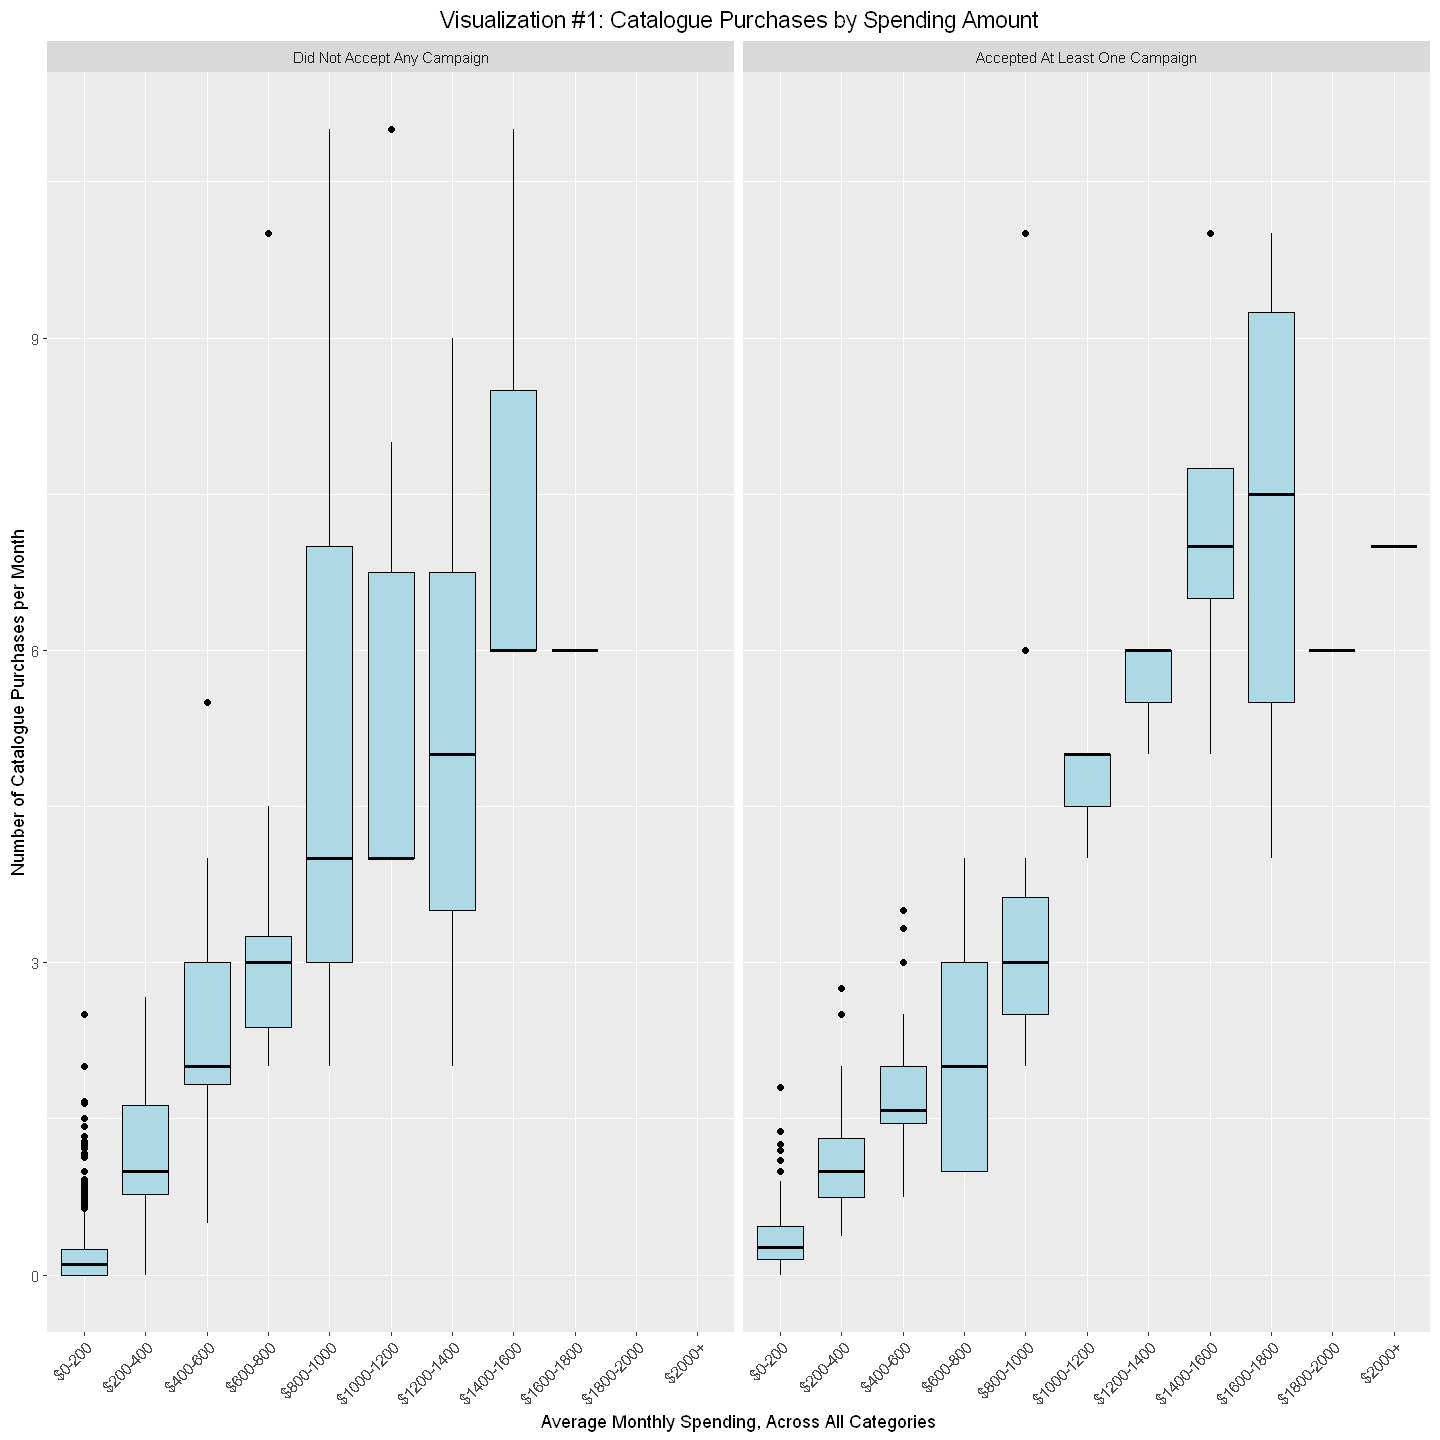

In [21]:
marketing_campaign_plotting_behavioural <- marketing_campaign %>%
    mutate( #engineering features for plot
        months_enrolled =  pmax(1, floor(Enrollment_Recency_Days / 30)),
        avg_total_spending_month = (MntWines + MntFruits + MntMeatProducts + 
                                    MntFishProducts + MntSweetProducts + MntGoldProds)/pmin(months_enrolled, 24), #make sure that we are only accounting for the past 2 years
        avg_catalog_purchases_month = NumCatalogPurchases/months_enrolled,
        spending_group = cut(avg_total_spending_month, 
                            breaks = c(seq(0, 2000, by = 200), Inf),
                            include.lowest = TRUE,
                            right = TRUE,
                            labels = c("$0-200", "$200-400", "$400-600", "$600-800", "$800-1000",
                                       "$1000-1200", "$1200-1400", "$1400-1600", "$1600-1800",
                                       "$1800-2000", "$2000+")
                              ),
        AcceptedCmpAny = factor(AcceptedCmpAny,
                                levels = c(0, 1),
                                labels = c("Did Not Accept Any Campaign", "Accepted At Least One Campaign"))
    ) 


options(repr.plot.width=12, repr.plot.height=12)
ggplot(marketing_campaign_plotting_behavioural, aes(x = spending_group, y = avg_catalog_purchases_month)) +
  geom_boxplot(fill = "lightblue", color = "black") +
  facet_wrap(~ AcceptedCmpAny) +
  labs(
    title = "Visualization #1: Catalogue Purchases by Spending Amount",
    x = "Average Monthly Spending, Across All Categories",
    y = "Number of Catalogue Purchases per Month"
  ) +
  scale_fill_brewer(palette="BuPu") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), plot.title = element_text(hjust = 0.5, size = 14)) 

#### Visualization #2
This plot communicates averages of each demographic group's shopping habits. It facilitates comparison within and across demographic variables, and can also indicate a significant presence of multicollinearity or notable outliers (e.g., income group "over 150,000"). We believe aggregate insights are the most suitable for our inferential question, even if it means neglecting distributions and outliers. 

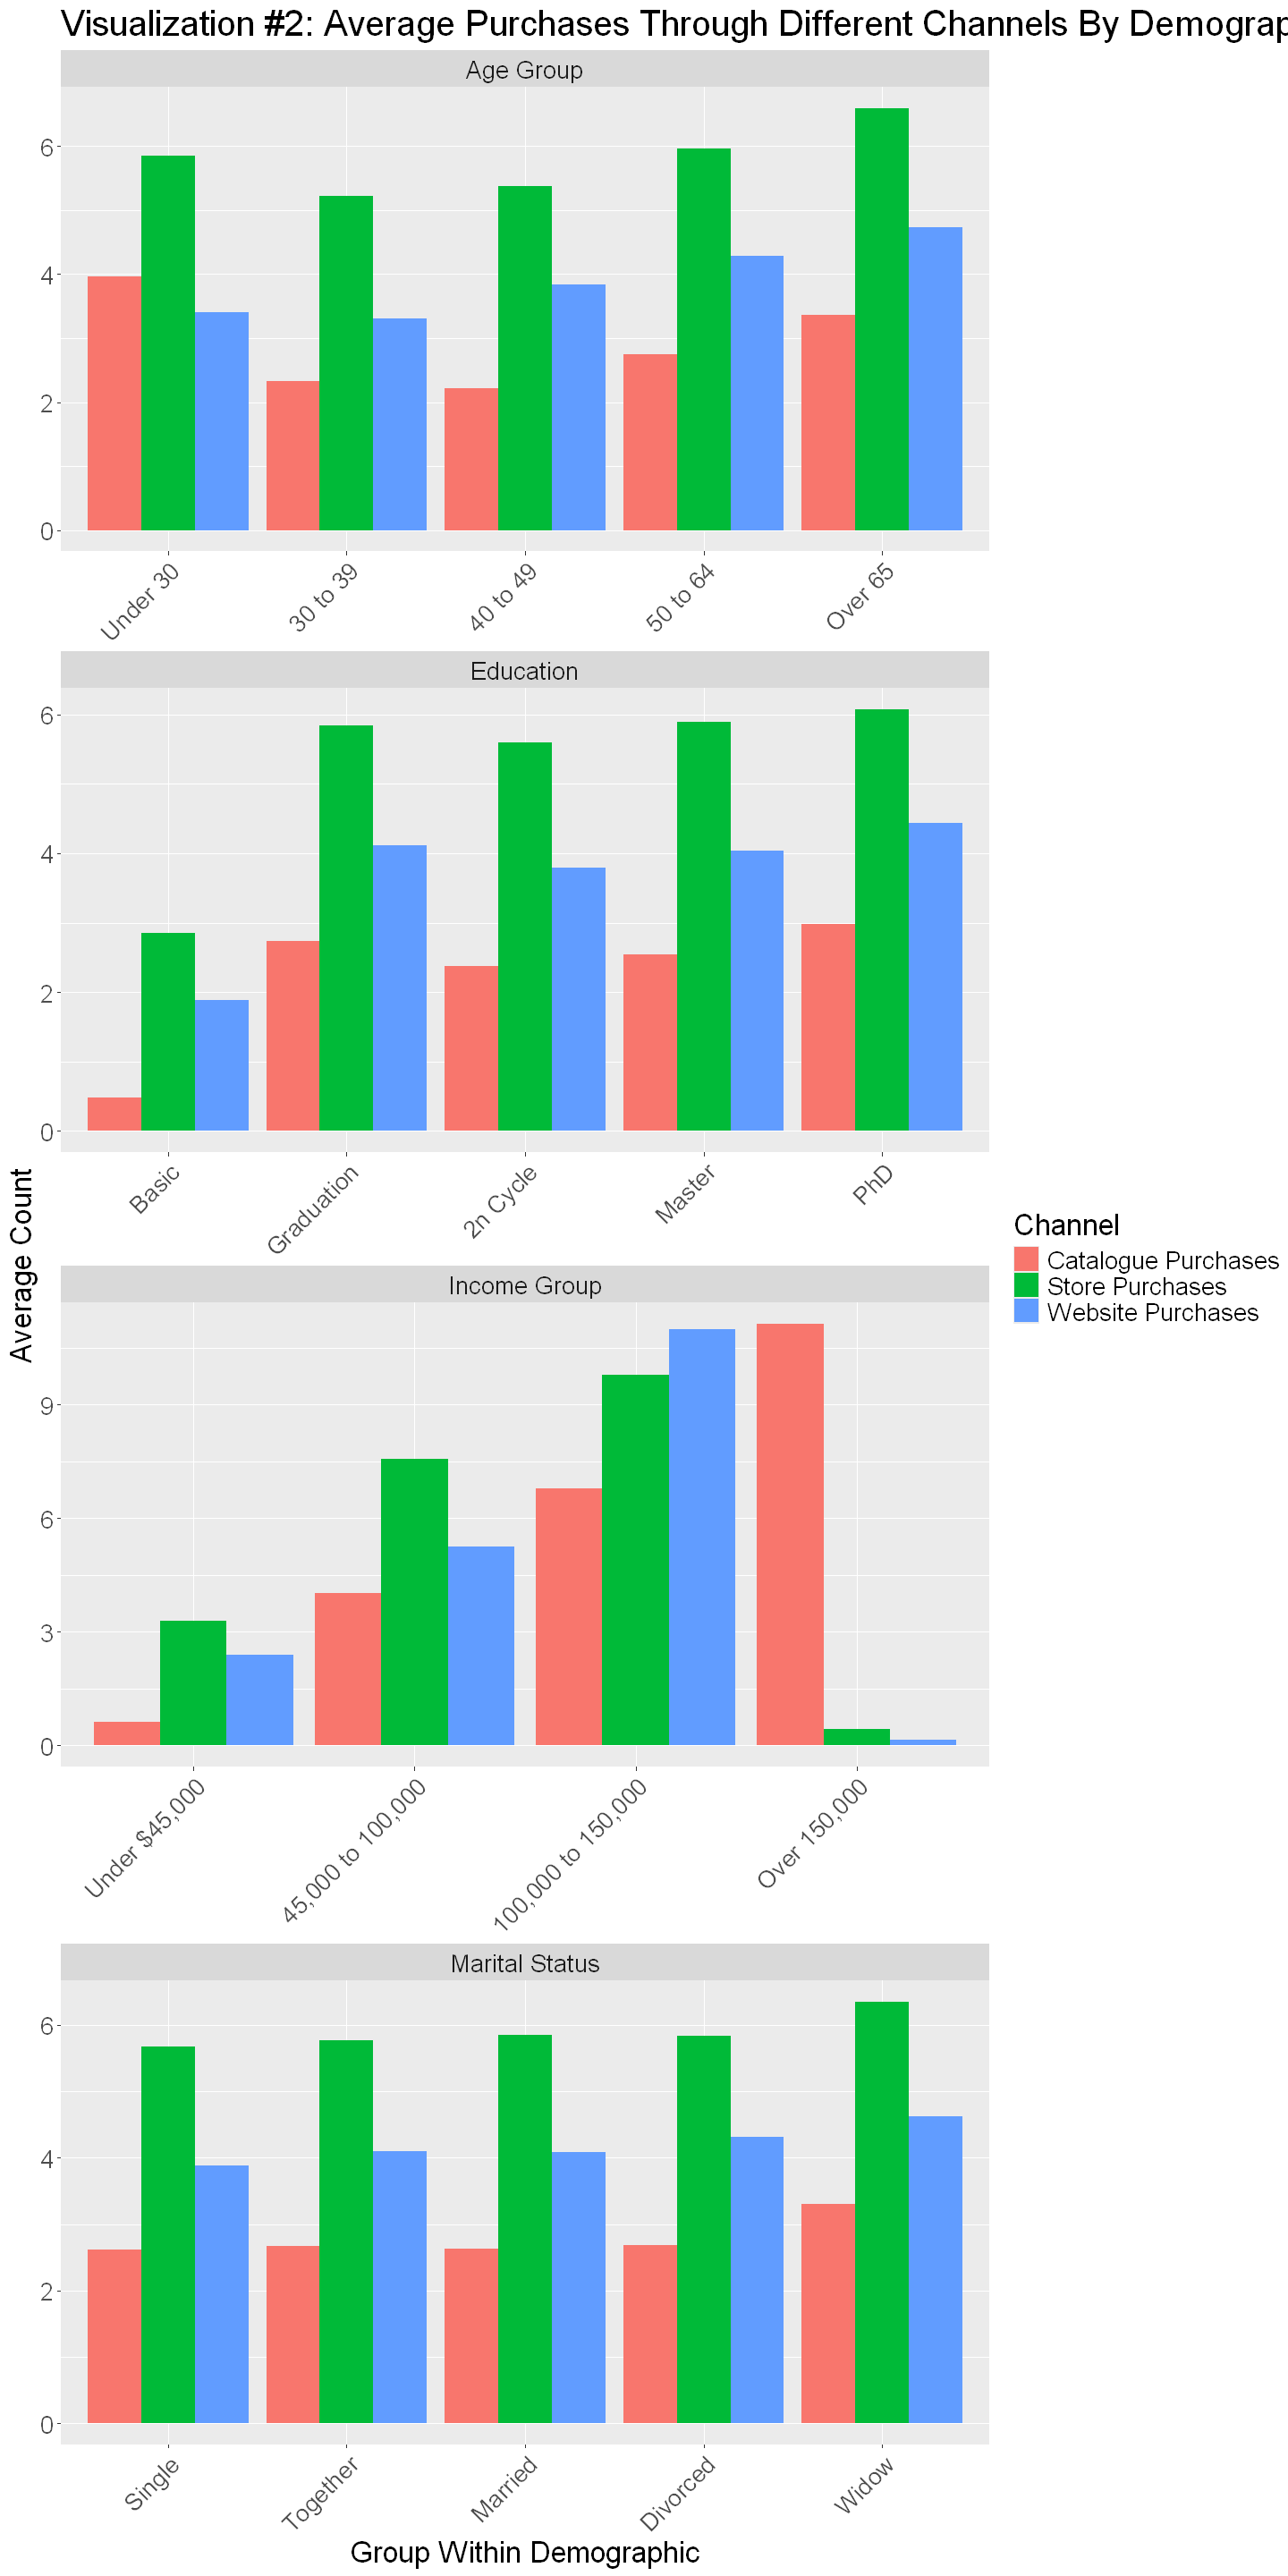

In [22]:
#wrangling to find at averages per group
marketing_campaign_plotting <- marketing_campaign %>%
    mutate( #creating groups with reasonable/commonly accepted boundaries for ease of viewing
           Age_Group = case_when(
               Age < 30 ~ 'Under 30',
               Age >= 30 & Age < 40 ~ '30 to 39',
               Age >= 40 & Age < 50 ~ '40 to 49',
               Age >= 50 & Age < 65 ~ '50 to 64',
               Age >= 65 ~ 'Over 65'),
           Income_Group = case_when(
               Income < 45000 ~ 'Under $45,000',
               Income >= 45000 & Income < 100000 ~ '45,000 to 100,000',
               Income >= 100000 & Income < 150000 ~ '100,000 to 150,000',
               Income >= 150000 ~ 'Over 150,000')
           ) %>%
    select(Age_Group, Income_Group, Education, Marital_Status, NumStorePurchases, NumCatalogPurchases, NumWebPurchases
          ) %>%
    pivot_longer(
        cols = c(Age_Group, Income_Group, Education, Marital_Status),
        names_to = 'Demographic',
        values_to = 'Group'
    ) %>%
    group_by(Demographic, Group) %>%
    summarize(
        avg_cat_purchases = mean(NumCatalogPurchases),
        avg_store_purchases = mean(NumStorePurchases),
        avg_web_purchases = mean(NumWebPurchases),
        .groups = "drop_last"
    )%>%
    pivot_longer(
        cols = c(avg_store_purchases, avg_cat_purchases, avg_web_purchases),
        names_to = 'Variable',
        values_to = 'Average'
    ) %>% 
    mutate(
        Variable = dplyr::recode(
            Variable,
            avg_cat_purchases = 'Catalogue Purchases',
            avg_store_purchases = 'Store Purchases',
            avg_web_purchases = 'Website Purchases'),
        Demographic = dplyr::recode(
            Demographic, 
            Age_Group = 'Age Group',
            Income_Group = 'Income Group',
            Marital_Status = 'Marital Status'),
        Group = factor(
            Group,
            levels = c(
                'Under 30', '30 to 39', '40 to 49', '50 to 64', 'Over 65',
                'Under $45,000', '45,000 to 100,000', '100,000 to 150,000', 'Over 150,000',
                'Basic', 'Graduation', '2n Cycle', 'Master', 'PhD', #2n Cycle is similar to a master's degree
                'Single', 'Together', 'Married', 'Divorced', 'Widow'
                ),
            ordered = TRUE
        )
    ) 

options(repr.plot.width=12, repr.plot.height=24)
marketing_campaign_plotting %>%
    ggplot(aes(x = Group, y = Average, fill = Variable)) +
    geom_bar(position = 'dodge', stat = 'identity') + 
    facet_wrap(~ Demographic, scales = 'free', ncol = 1) + 
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        text = element_text(size = 20)) +
    labs(
        y = 'Average Count',
        x = 'Group Within Demographic' ,
        fill = 'Channel') +
    ggtitle('Visualization #2: Average Purchases Through Different Channels By Demographic Groups')


# Methods: Plan
Given that `NumCatalogPurchases` is a non-negative integer count response, we propose using a Poisson regression model. Given the inferential goal and a large set of potential covariates, we will perform variable selection using the LASSO. After selection, we will fit a post-LASSO Poisson additive model using the selected variables for inference. This approach simplifies the model, aids interpretation, and yields practical business insights.

To avoid “double-dipping”, we first split the data into a training set (70%) for variable selection and model development, and a held-out test set (30%) for final model evaluation. LASSO variable selection will be applied only to the training data, preserving the test set for unbiased final evaluation. 

While forward selection is conventional, it becomes computationally expensive and unstable with many covariates; its greedy, marginal-improvement approach can lead to overfitting and poor reproducibility. LASSO efficiently handles high-dimensional spaces via L1 regularization using the Poisson family. The regularization parameter λ will be chosen via 5-fold cross-validation using `lambda.min`. This approach respects the count nature of the response and performs continuous shrinkage with automatic selection.

The final Poisson model (fitted on the selected variables) will be applied to the held-out test set to compute predictive performance metrics. No further model adjustments will be made after test set evaluation to prevent information leakage.

# Assumptions and Limitations
*Assumptions*
- Independence: Observations are assumed independent. This is plausible if each row represents a distinct customer, but could be violated if customers belong to the same household.
- Mean-variance equality (equidispersion): Poisson regression assumes mean equals variance. Real-world count data often exhibit overdispersion (variance > mean). We will check for overdispersion after refitting the final model; if present, we will refit using the quasipoisson family to adjust standard errors.
- Log-linearity: The log of the expected count is assumed to be linear in the predictors. This may be violated for variables like `Income` or `Age`, whose effects could be nonlinear.

*Limitations*
- Multicollinearity: There may be multicollinearity among some variables, such as income and amount spent on certain categories. LASSO naturally handles this during selection, but we'll also check this using `vif()` before fitting the final model to ensure this is not an issue.
- Overdispersion: If overdispersion is present and not addressed, standard errors from the final Poisson model will be underestimated, leading to inflated Type I errors. The quasipoisson adjustment partially remedies this but does not change coefficient estimates.
- No causal interpretation: The data are observational. Any associations identified should not be interpreted as causal due to potential confounding.
- LASSO bias: LASSO shrinks coefficients toward zero, which is why we refit without penalization. However, variable selection itself may be unstable with small sample sizes or highly correlated predictors.
- Class imbalance: Some categorical predictors (e.g., campaign acceptance variables) may have very few positive cases, leading to unstable coefficient estimates.
- Categorical variable selection: LASSO may select only some dummies from a categorical set, complicating interpretation (coefficients are relative to the reference level). If any dummy from a categorical predictor is selected, we will include all corresponding dummy variables for that categorical variable in the final model.

In [23]:
# set seed for reproducibility
set.seed(404)

# split data 70/30 randomly for training and test
n_total <- nrow(marketing_campaign)
n_train <- floor(0.7 * n_total)

# create design matrices
train_indices <- sample(1:n_total, size = n_train)
train_data <- marketing_campaign[train_indices, ]
test_data <- marketing_campaign[-train_indices, ]

x_train <- model.matrix(~ . - NumCatalogPurchases - 1, data = train_data)
x_test  <- model.matrix(~ . - NumCatalogPurchases - 1, data = test_data)

y_train <- train_data$NumCatalogPurchases
y_test  <- test_data$NumCatalogPurchases

In [24]:
# Run 5-fold cross-validated LASSO Poisson regression
cv_lasso <- cv.glmnet(x_train, y_train, 
                      family = "poisson", 
                      alpha = 1, 
                      nfolds = 5,
                      type.measure = "deviance",
                      standardize = TRUE)
lasso_model <- glmnet(x_train, y_train, 
                      family = "poisson", 
                      alpha = 1, 
                      lambda = cv_lasso$lambda.min)


coef_lasso <- as.matrix(coef(lasso_model))
selected_lasso_vars <- rownames(coef_lasso)[coef_lasso[, 1] != 0]
selected_lasso_vars <- selected_lasso_vars[selected_lasso_vars != "(Intercept)"]

cat("\nLASSO selected", length(selected_lasso_vars), "variables:\n")
print(coef_lasso[coef_lasso[, 1] != 0, , drop = FALSE])


LASSO selected 26 variables:
                                   s0
(Intercept)             -9.735363e-02
Education2n Cycle        4.803720e-02
EducationBasic          -2.655160e-01
EducationMaster         -1.878476e-02
EducationPhD             2.225682e-02
Marital_StatusDivorced  -4.930634e-02
Marital_StatusMarried    1.433813e-03
Marital_StatusTogether  -1.214245e-03
Marital_StatusWidow      1.066197e-01
Income                   6.835217e-06
Kidhome                 -4.773238e-01
Teenhome                -5.809152e-02
Recency                  6.628096e-05
MntWines                 5.384987e-04
MntFruits                1.164666e-04
MntMeatProducts          6.734069e-04
MntFishProducts          1.146936e-03
MntSweetProducts         6.141506e-04
MntGoldProds             1.544462e-03
NumDealsPurchases        8.679821e-02
NumWebPurchases          4.071504e-02
NumStorePurchases        1.896468e-02
NumWebVisitsMonth       -8.832836e-02
Complain1                1.538991e-01
Response1           

Although LASSO selected 26 variables, it retained only some levels of the categorical variables rather than all. To ensure robustness in interpretation, we will include the full set of dummy variables for each selected categorical variable in the final model.

In [25]:
# store the selected variables
selected_vars <- c(
  "Education", "Marital_Status", "Income", "Kidhome", "Teenhome",
  "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts",
  "MntGoldProds", "NumDealsPurchases", "NumWebPurchases", "NumStorePurchases",
  "NumWebVisitsMonth", "Complain", "Response", "Age", "Enrollment_Recency_Days",
  "AcceptedCmpAny"
)

In [26]:
# Fit Poisson model with LASSO-selected variables and compute VIF to assess multicollinearity
vif_refit <- glm(
  NumCatalogPurchases ~ Education + Marital_Status + Income + Kidhome + Teenhome +
    MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts +
    MntGoldProds + NumDealsPurchases + NumWebPurchases + NumStorePurchases +
    NumWebVisitsMonth + Complain + Response + Age + Enrollment_Recency_Days +
    AcceptedCmpAny,
  data = train_data,
  family = poisson()
)
vif(vif_refit)

,GVIF,Df,GVIF^(1/(2*Df))
Education,1.510772,4,1.052931
Marital_Status,1.207081,4,1.023804
Income,2.958724,1,1.720094
Kidhome,1.679865,1,1.296096
Teenhome,1.899976,1,1.378396
MntWines,2.270006,1,1.506654
MntFruits,1.598851,1,1.264457
MntMeatProducts,3.007419,1,1.734191
MntFishProducts,1.649402,1,1.284291
MntSweetProducts,1.475162,1,1.214563


VIF values are all below 5, indicating no problematic multicollinearity. We can now proceed to the final model fitting using the test set.

In [27]:
# Fit the final Poisson model with the selected variables
infer_model<- glm(
  NumCatalogPurchases ~ Education + Marital_Status + Income + Kidhome + Teenhome +
    MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts +
    MntGoldProds + NumDealsPurchases + NumWebPurchases + NumStorePurchases +
    NumWebVisitsMonth + Complain + Response + Age + Enrollment_Recency_Days +
    AcceptedCmpAny,
  data = test_data,
  family = poisson()
)

In [28]:
# Check multicollinearity with a Quasipoisson model
infer_quasi <- glm(
    formula = NumCatalogPurchases ~ Education + Marital_Status + Income + Kidhome + Teenhome +
    MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts +
    MntGoldProds + NumDealsPurchases + NumWebPurchases + NumStorePurchases +
    NumWebVisitsMonth + Complain + Response + Age + Enrollment_Recency_Days +
    AcceptedCmpAny,
    data = test_data,
    family = quasipoisson)

summary(infer_quasi)


Call:
glm(formula = NumCatalogPurchases ~ Education + Marital_Status + 
    Income + Kidhome + Teenhome + MntWines + MntFruits + MntMeatProducts + 
    MntFishProducts + MntSweetProducts + MntGoldProds + NumDealsPurchases + 
    NumWebPurchases + NumStorePurchases + NumWebVisitsMonth + 
    Complain + Response + Age + Enrollment_Recency_Days + AcceptedCmpAny, 
    family = quasipoisson, data = test_data)

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)             -3.794e-01  2.423e-01  -1.566 0.117921    
EducationBasic          -1.016e-01  3.566e-01  -0.285 0.775877    
EducationGraduation      9.257e-02  8.662e-02   1.069 0.285662    
EducationMaster         -2.492e-02  1.018e-01  -0.245 0.806657    
EducationPhD             4.372e-02  9.935e-02   0.440 0.660072    
Marital_StatusDivorced   1.885e-01  9.290e-02   2.029 0.042840 *  
Marital_StatusMarried    1.441e-02  6.954e-02   0.207 0.835918    
Marital_StatusTogether   9.940e-02  7.26

The dispersion parameter is about 0.9177682, indicating no sign of overdispersion. Therefore, we can proceed with a regular Poisson model.

In [29]:
summary(infer_model)


Call:
glm(formula = NumCatalogPurchases ~ Education + Marital_Status + 
    Income + Kidhome + Teenhome + MntWines + MntFruits + MntMeatProducts + 
    MntFishProducts + MntSweetProducts + MntGoldProds + NumDealsPurchases + 
    NumWebPurchases + NumStorePurchases + NumWebVisitsMonth + 
    Complain + Response + Age + Enrollment_Recency_Days + AcceptedCmpAny, 
    family = poisson(), data = test_data)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -3.794e-01  2.529e-01  -1.500 0.133634    
EducationBasic          -1.016e-01  3.722e-01  -0.273 0.784964    
EducationGraduation      9.257e-02  9.042e-02   1.024 0.305974    
EducationMaster         -2.492e-02  1.062e-01  -0.235 0.814550    
EducationPhD             4.372e-02  1.037e-01   0.422 0.673360    
Marital_StatusDivorced   1.885e-01  9.697e-02   1.944 0.051882 .  
Marital_StatusMarried    1.441e-02  7.259e-02   0.198 0.842654    
Marital_StatusTogether   9.940e-02  7.578e-

In [30]:
# Visualize the post-LASSO Poisson model results with a table
results_table <- tidy(
    infer_model,
    conf.int = TRUE,
    conf.level = 0.95,
    exponentiate = TRUE #for interpretation of counts, rather than log counts
) %>% 
    filter(term != "(Intercept)") %>%
    arrange(desc(estimate)) %>%
    rename('exp(estimate)' = estimate)
as.data.frame(results_table)

term,exp(estimate),std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Marital_StatusDivorced,1.2074579,9.696838e-02,1.94411016,5.188217e-02,0.9972860,1.4587796
Marital_StatusTogether,1.1045108,7.577998e-02,1.31172540,1.896128e-01,0.9525492,1.2821470
NumDealsPurchases,1.1044159,1.621855e-02,6.12364297,9.145971e-10,1.0693654,1.1395829
EducationGraduation,1.0969849,9.042183e-02,1.02370631,3.059740e-01,0.9214246,1.3136538
AcceptedCmpAny,1.0622670,6.865918e-02,0.87978461,3.789760e-01,0.9278168,1.2143919
NumWebPurchases,1.0512684,1.437926e-02,3.47705136,5.069607e-04,1.0222556,1.0815372
EducationPhD,1.0446879,1.037104e-01,0.42154076,6.733603e-01,0.8541527,1.2828713
Response1,1.0209395,7.653092e-02,0.27078251,7.865583e-01,0.8783204,1.1856523
Marital_StatusMarried,1.0145137,7.259123e-02,0.19849992,8.426540e-01,0.8806112,1.1705845


In [31]:
# Filter for statistically significant results and visualize it as a table
results_table_significant <- tidy(
    infer_model,
    conf.int = TRUE,
    conf.level = 0.95,
    exponentiate = TRUE
) %>% 
    filter(term != "(Intercept)") %>%
    filter(p.value < 0.05) %>%  # Keep only significant predictors
    arrange(desc(estimate)) %>%
    rename('exp(estimate)' = estimate)

as.data.frame(results_table_significant)

term,exp(estimate),std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NumDealsPurchases,1.1044159,1.621855e-02,6.123643,9.145971e-10,1.0693654,1.1395829
NumWebPurchases,1.0512684,1.437926e-02,3.477051,5.069607e-04,1.0222556,1.0815372
MntGoldProds,1.0011527,4.678195e-04,2.462583,1.379404e-02,1.0002297,1.0020659
MntWines,1.0004745,1.068312e-04,4.440780,8.963329e-06,1.0002650,1.0006840
MntMeatProducts,1.0004329,1.419074e-04,3.049653,2.291056e-03,1.0001552,1.0007119
Enrollment_Recency_Days,1.0003506,1.429672e-04,2.452199,1.419863e-02,1.0000705,1.0006312
Income,1.0000121,2.742075e-06,4.429242,9.456502e-06,1.0000066,1.0000174
NumWebVisitsMonth,0.8889963,2.145477e-02,-5.484201,4.153415e-08,0.8519892,0.9267332
Kidhome,0.5739581,8.926625e-02,-6.219583,4.984779e-10,0.4813724,0.6830563


## Interpretation and Discussion

After using Poisson LASSO to select important features and fitting the post-LASSO Poisson model on the inference set using only the selected features, the final inferential Poisson model revealed nine statistically significant predictors of catalog purchases (p < 0.05) at a 5% significance level. Our results indicate no sign of overdispersion (dispersion parameter = 0.9177682), so the standard error results can be interpreted somewhat confidently. There was also no sign of multicollinearity (all VIFs < 5).

Income, spending on wines, meat products, and gold products, number of deal purchases, number of web purchases, and enrollment recency days were positively associated with catalogue purchases. Higher income, higher purchasing behaviour, and recency in enrollment correlate to higher catalogue purchases, which is what we expected. In contrast, having children at home (`Kidhome`) and the number of web visits per month were negatively associated. This may be tied to parents having less free time/money to make purchases. Web visitors make fewer catalogue purchases, since they may prefer modern digital forms of advertising. Marital status (`Divorced`) and age showed marginal significance (p < 0.10). Businesses may wish to target different audiences with different tactics: parents with children, web visitors, and customers who spend on wine, meat, and gold products.

A limitation in interpreting our results is the inability to make causal conclusions. Since the data was collected from an observational study, we can only make associative conclusions, with `NumDealsPurchases` as an example:

>"We estimate that keeping all other variables in the model constant, at any value, an increase of one in the number of purchases made with a discount is associated with a change in the mean number of catalog purchases of customers by a factor of $\approx1.104$."

Considering the drawbacks to our analysis, we may wish to improve our model by addressing the class imbalance in certain categorical variables by performing an upsampling method. In the feature selection process, we might also consider other possible selection models, such as a stepwise algorithm, if we can aggregate some of the variables so that we don't work with a "wide" dataset.

In future analyses, questions may be asked about causal relationships. Businesses may want to introduce A/B testing for different marketing campaigns to make causal conclusions about marketing campaigns and how they relate to consumer behaviour.

### AI Disclosure 
Generative AI models were used to proofread writing for spelling and grammar.

### Citations 

imakash3011. (n.d.). _Customer Personality Analysis_. Kaggle. Retrieved March 14, 2026, from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
